<a href="https://colab.research.google.com/github/KaueOPG/DCC127---Mineracao-de-Dados/blob/main/Trabalho4_Regras_de_Associacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho 4 - Regras de Associação

## Dayane Guimarães Gomes Godoy - 202265554C
## Kauê Oliveira Paraízo Garcia - 202265517B

### Importação de Dados

In [ ]:
!pip install pyvis

In [ ]:
# Bibliotecas

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from mlxtend.frequent_patterns import apriori, association_rules
from pyvis.network import Network
from IPython.display import HTML
import warnings
warnings.filterwarnings("ignore")

In [ ]:
url = "https://docs.google.com/spreadsheets/d/1V0zZpBN10yXMKuRiusJoPXycHAnYlETQtlHN5O07xAw/export?format=csv"

df = pd.read_csv(url)

df.head()

,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,30/10/2016 09:58,morning,weekend
1,3,Hot chocolate,30/10/2016 10:07,morning,weekend
2,3,Jam,30/10/2016 10:07,morning,weekend
3,3,Cookies,30/10/2016 10:07,morning,weekend
4,4,Muffin,30/10/2016 10:08,morning,weekend


## Análise Inicial

### Princípio

In [ ]:
print(f"Total de linhas (itens comprados): {df.shape[0]}")
print(f"Total de transações únicas: {df['Transaction'].nunique()}")

Total de linhas (itens comprados): 13604
Total de transações únicas: 6274


In [ ]:
print("--- Valores Nulos por Coluna ---")
print(df.isnull().sum())

print("\n--- Porcentagem de Valores Nulos ---")
print((df.isnull().sum() / len(df)) * 100)

--- Valores Nulos por Coluna ---
Transaction        0
Item               0
date_time          0
period_day         0
weekday_weekend    0
dtype: int64

--- Porcentagem de Valores Nulos ---
Transaction        0.0
Item               0.0
date_time          0.0
period_day         0.0
weekday_weekend    0.0
dtype: float64


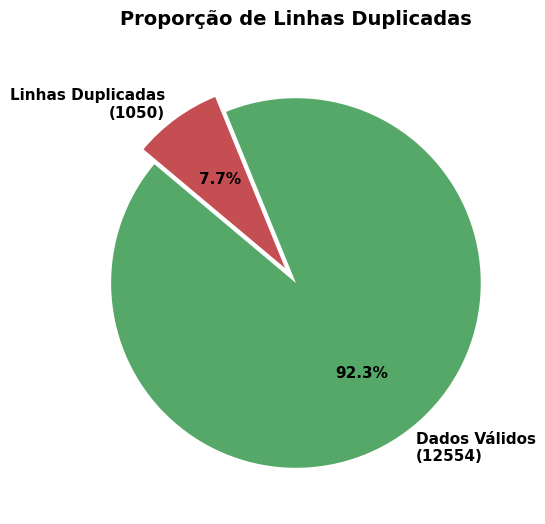

In [ ]:
# 1. Calculando os valores
total_original = df.shape[0]
total_duplicadas = df.duplicated().sum()
total_sem_duplicadas = total_original - total_duplicadas

# 2. Dados para o gráfico
valores = [total_sem_duplicadas, total_duplicadas]
labels = [f'Dados Válidos\n({total_sem_duplicadas})', f'Linhas Duplicadas\n({total_duplicadas})']
cores = ['#55A868', '#C44E52']

plt.figure(figsize=(6, 6))
plt.pie(
    valores,
    labels=labels,
    colors=cores,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 11, 'weight': 'bold'},
    explode=(0, 0.1)
)

plt.title('Proporção de Linhas Duplicadas', fontsize=14, pad=20, weight='bold')
plt.show()

In [ ]:
# REVER REVER REVER REVER REVER REVER REVER REVER - Duplicata - excluir ou somar? Esta Excluindo

df = df.drop_duplicates()
print(f"Novo total de linhas após remover duplicadas: {df.shape[0]}")

Novo total de linhas após remover duplicadas: 12554


### Coluna Transaction

In [ ]:
periodos_por_id = df.groupby('Transaction')['period_day'].nunique()
ids_com_varios_periodos = periodos_por_id[periodos_por_id > 1]

dias_por_id = df.groupby('Transaction')['weekday_weekend'].nunique()
ids_com_varios_dias = dias_por_id[dias_por_id > 1]

print("--- Análise de Consistência dos IDs ---")
print(f"Total de IDs com mais de um período (ex: manhã e noite): {len(ids_com_varios_periodos)}")
print(f"Total de IDs misturando Dia de Semana e Fim de Semana: {len(ids_com_varios_dias)}")

if len(ids_com_varios_periodos) > 0:
    print("\nExemplo de IDs com inconsistência de período:")
    print(ids_com_varios_periodos.head())

--- Análise de Consistência dos IDs ---
Total de IDs com mais de um período (ex: manhã e noite): 0
Total de IDs misturando Dia de Semana e Fim de Semana: 0


In [ ]:
datas_por_id = df.groupby('Transaction')['date_time'].nunique()
ids_com_varias_datas = datas_por_id[datas_por_id > 1]

print("--- Análise de Consistência de Data/Hora por ID ---")
print(f"Total de IDs com mais de um date_time: {len(ids_com_varias_datas)}")

if len(ids_com_varias_datas) > 0:
    print("\nExemplo de IDs com problemas de data/hora:")
    print(df[df['Transaction'].isin(ids_com_varias_datas.index)].head(10))

--- Análise de Consistência de Data/Hora por ID ---
Total de IDs com mais de um date_time: 0


### Coluna Item

In [ ]:
todos_os_itens = sorted(df['Item'].unique())

print(f"O dataset possui {len(todos_os_itens)} itens únicos.\n")
print("Lista completa de itens:")
for item in todos_os_itens:
    print(f"- {item}")

O dataset possui 90 itens únicos.

Lista completa de itens:
- Afternoon with the baker
- Alfajores
- Argentina Night
- Art Tray
- Baguette
- Bakewell
- Bare Popcorn
- Basket
- Bowl Nic Pitt
- Bread
- Bread Pudding
- Brioche and salami
- Brownie
- Cake
- Caramel bites
- Cherry me Dried fruit
- Chicken Stew
- Chicken sand
- Chocolates
- Christmas common
- Coffee
- Coffee granules
- Coke
- Cookies
- Crepes
- Crisps
- Drinking chocolate spoons
- Duck egg
- Dulce de Leche
- Eggs
- Ella's Kitchen Pouches
- Empanadas
- Extra Salami or Feta
- Fairy Doors
- Farm House
- Focaccia
- Frittata
- Fudge
- Gingerbread syrup
- Granola
- Hack the stack
- Half slice Monster
- Hearty & Seasonal
- Honey
- Hot chocolate
- Jam
- Jammie Dodgers
- Juice
- Keeping It Local
- Kids biscuit
- Lemon and coconut
- Medialuna
- Mighty Protein
- Mineral water
- Mortimer
- Muesli
- Muffin
- My-5 Fruit Shoot
- Nomad bag
- Olum & polenta
- Panatone
- Pastry
- Pick and Mix Bowls
- Pintxos
- Polenta
- Postcard
- Raspberry s

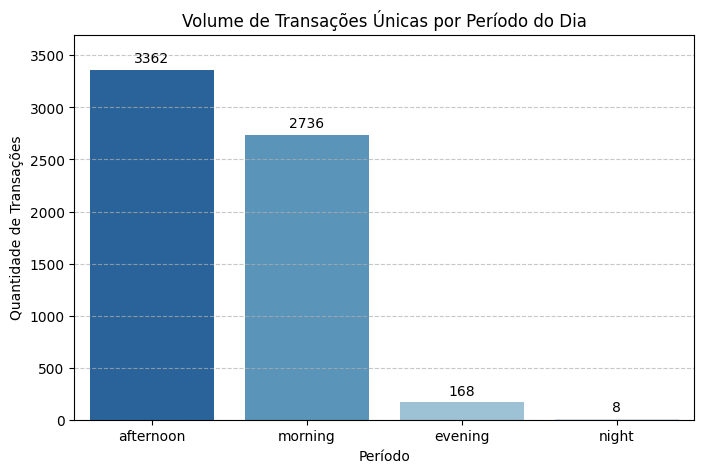

In [ ]:
transacoes_por_periodo = df.groupby('period_day')['Transaction'].nunique().reset_index()
transacoes_por_periodo = transacoes_por_periodo.sort_values(by='Transaction', ascending=False)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=transacoes_por_periodo, x='period_day', y='Transaction', palette='Blues_r')

for container in ax.containers:
    labels = [f'{int(v.get_height())}' if v.get_height() > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, padding=3, fontsize=10)

plt.title('Volume de Transações Únicas por Período do Dia')
plt.xlabel('Período')
plt.ylabel('Quantidade de Transações')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, transacoes_por_periodo['Transaction'].max() * 1.1)
plt.show()

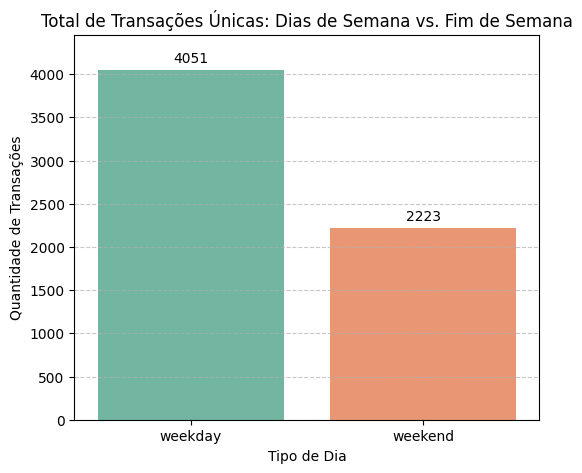

In [ ]:
transacoes_por_tipo_dia = df.groupby('weekday_weekend')['Transaction'].nunique().reset_index()

plt.figure(figsize=(6, 5))
ax = sns.barplot(data=transacoes_por_tipo_dia, x='weekday_weekend', y='Transaction', palette='Set2')

for container in ax.containers:
    labels = [f'{int(v.get_height())}' if v.get_height() > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, padding=3, fontsize=10)

plt.title('Total de Transações Únicas: Dias de Semana vs. Fim de Semana')
plt.xlabel('Tipo de Dia')
plt.ylabel('Quantidade de Transações')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, transacoes_por_tipo_dia['Transaction'].max() * 1.1)
plt.show()

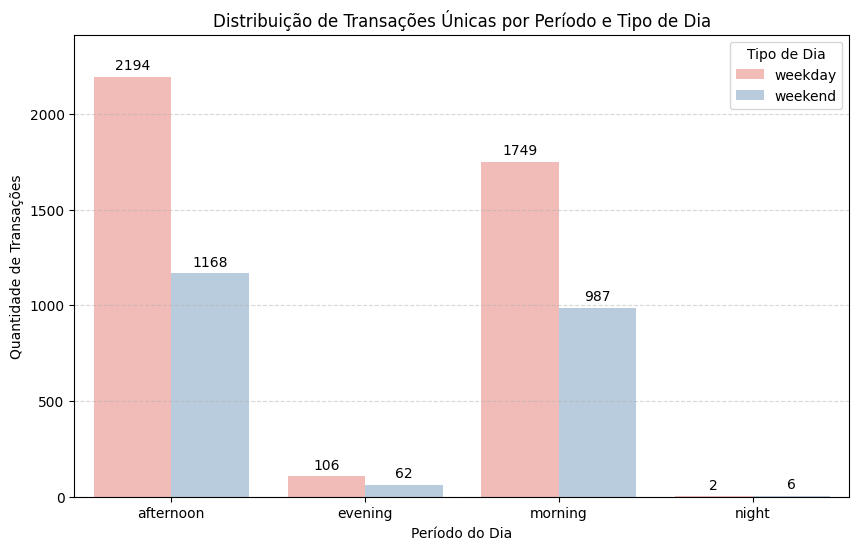

In [ ]:
analise_cruzada = df.groupby(['period_day', 'weekday_weekend'])['Transaction'].nunique().reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=analise_cruzada, x='period_day', y='Transaction', hue='weekday_weekend', palette='Pastel1')

for container in ax.containers:
    labels = [f'{int(v.get_height())}' if v.get_height() > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, padding=3, fontsize=10)

plt.title('Distribuição de Transações Únicas por Período e Tipo de Dia')
plt.xlabel('Período do Dia')
plt.ylabel('Quantidade de Transações')
plt.legend(title='Tipo de Dia')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.ylim(0, analise_cruzada['Transaction'].max() * 1.1)
plt.show()

In [ ]:
# Lista de itens que não são comida/bebida
itens_coisas = [
    'Fairy Doors', 'Postcard', 'Tshirt', "Valentine's card",
    'Afternoon with the baker', 'Art Tray', 'The BART', 'The Nomad', 'Nomad bag'
]

print(itens_coisas)

['Fairy Doors', 'Postcard', 'Tshirt', "Valentine's card", 'Afternoon with the baker', 'Art Tray', 'The BART', 'The Nomad', 'Nomad bag']


### Coluna Date_Time

In [ ]:
df['date_time'] = pd.to_datetime(df['date_time'], format='%d/%m/%Y %H:%M')

df['time_only'] = df['date_time'].dt.time

print("--- Horários Gerais de Operação da Loja ---")
print(f"Primeira transação registrada do dia (Mínimo): {df['time_only'].min().strftime('%H:%M')}")
print(f"Última transação registrada do dia (Máximo): {df['time_only'].max().strftime('%H:%M')}")
print("-" * 42)

print("\n--- Verificação dos Períodos do Dia ---")
verificacao_periodos = df.groupby('period_day')['time_only'].agg(['min', 'max', 'count'])

verificacao_periodos['min'] = verificacao_periodos['min'].apply(lambda x: x.strftime('%H:%M'))
verificacao_periodos['max'] = verificacao_periodos['max'].apply(lambda x: x.strftime('%H:%M'))

print(verificacao_periodos)

--- Horários Gerais de Operação da Loja ---
Primeira transação registrada do dia (Mínimo): 01:21
Última transação registrada do dia (Máximo): 23:29
------------------------------------------

--- Verificação dos Períodos do Dia ---
              min    max  count
period_day                     
afternoon   12:00  16:59   7082
evening     17:00  20:40    324
morning     01:21  11:59   5139
night       21:42  23:29      9


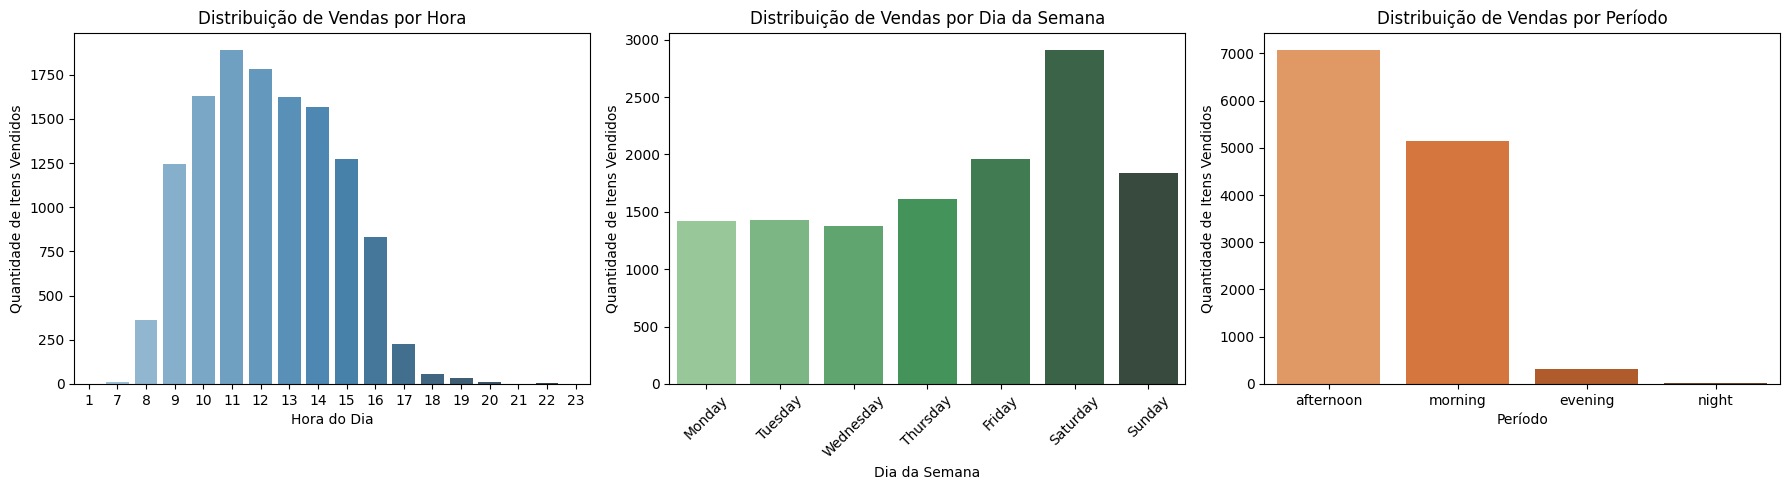

In [ ]:
df['date_time'] = pd.to_datetime(df['date_time'], format='%d/%m/%Y %H:%M')

df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.day_name()
df['month'] = df['date_time'].dt.month_name()

dias_ordenados = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=dias_ordenados, ordered=True)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.countplot(data=df, x='hour', palette='Blues_d')
plt.title('Distribuição de Vendas por Hora')
plt.xlabel('Hora do Dia')
plt.ylabel('Quantidade de Itens Vendidos')

plt.subplot(1, 3, 2)
sns.countplot(data=df, x='day_of_week', palette='Greens_d')
plt.title('Distribuição de Vendas por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Quantidade de Itens Vendidos')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
sns.countplot(data=df, x='period_day', palette='Oranges_d',
              order=df['period_day'].value_counts().index)
plt.title('Distribuição de Vendas por Período')
plt.xlabel('Período')
plt.ylabel('Quantidade de Itens Vendidos')

plt.tight_layout()
plt.show()

In [ ]:
print("--- Porcentagem de Vendas por Período do Dia ---")
print(df['period_day'].value_counts(normalize=True) * 100)

print("\n--- Porcentagem de Vendas: Semana vs Fim de Semana ---")
print(df['weekday_weekend'].value_counts(normalize=True) * 100)

--- Porcentagem de Vendas por Período do Dia ---
period_day
afternoon    56.412299
morning      40.935160
evening       2.580851
night         0.071690
Name: proportion, dtype: float64

--- Porcentagem de Vendas: Semana vs Fim de Semana ---
weekday_weekend
weekday    62.11566
weekend    37.88434
Name: proportion, dtype: float64


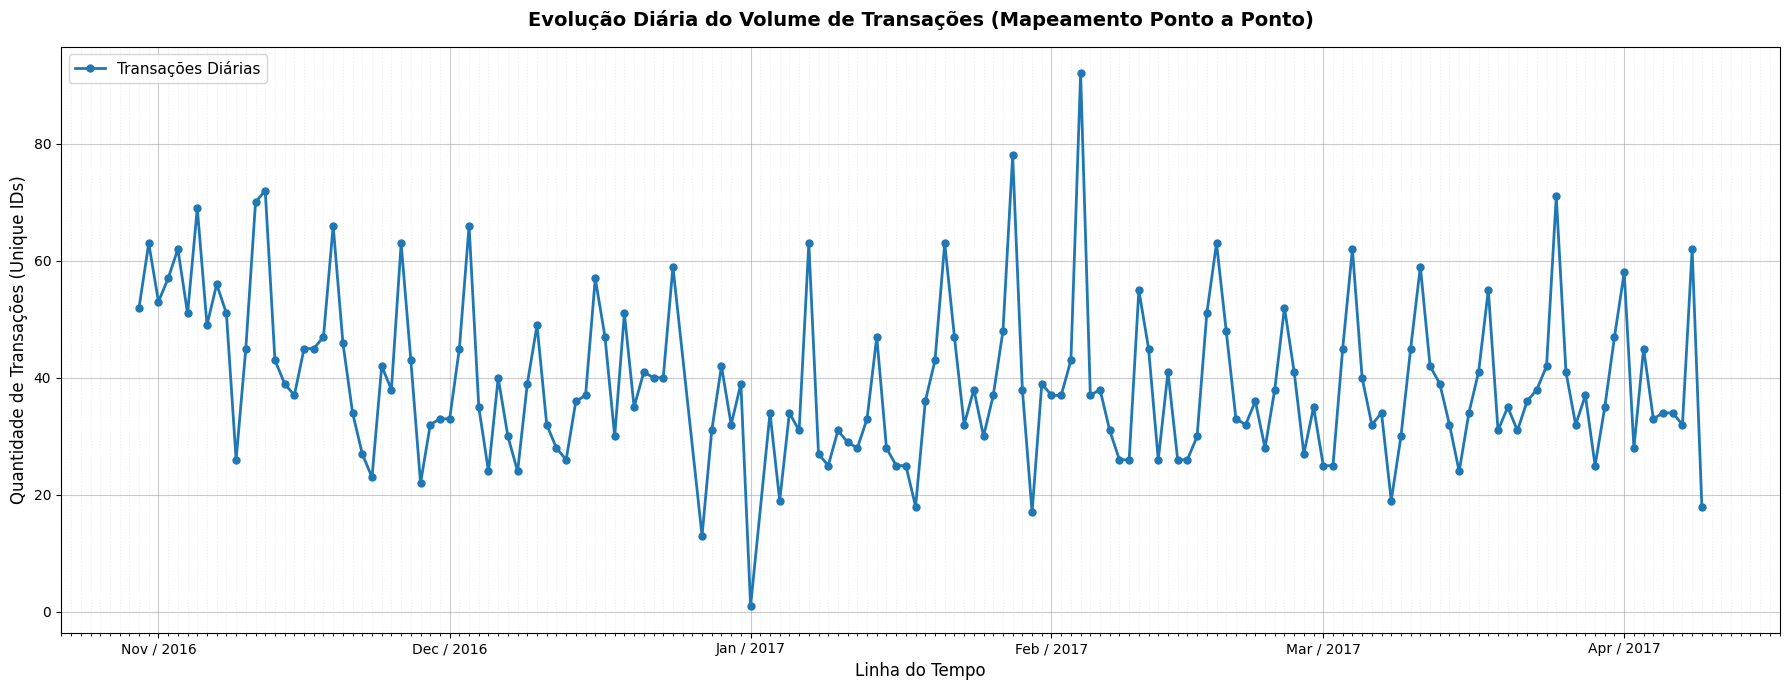

In [ ]:
df['date_time'] = pd.to_datetime(df['date_time'], format='%d/%m/%Y %H:%M')
df['date_only'] = df['date_time'].dt.date

vendas_por_dia = df.groupby('date_only')['Transaction'].nunique().reset_index()
vendas_por_dia['date_only'] = pd.to_datetime(vendas_por_dia['date_only'])

plt.figure(figsize=(18, 7))

plt.plot(vendas_por_dia['date_only'], vendas_por_dia['Transaction'],
         color='#1f77b4', linewidth=2, linestyle='-', marker='o', markersize=5, label='Transações Diárias')

ax = plt.gca()

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b / %Y'))

ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))

plt.title('Evolução Diária do Volume de Transações (Mapeamento Ponto a Ponto)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Linha do Tempo', fontsize=12)
plt.ylabel('Quantidade de Transações (Unique IDs)', fontsize=12)

plt.grid(True, which='major', color='#999999', linestyle='-', alpha=0.5)

plt.grid(True, which='minor', color='#e0e0e0', linestyle=':', alpha=0.6)

plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
df['date_time'] = pd.to_datetime(df['date_time'], format='%d/%m/%Y %H:%M')
df['date_only'] = df['date_time'].dt.date

primeiro_dia = df['date_only'].min()
ultimo_dia = df['date_only'].max()

total_dias_calendario = (ultimo_dia - primeiro_dia).days + 1

dias_com_vendas = df['date_only'].nunique()

dias_sem_vendas = total_dias_calendario - dias_com_vendas

print("--- Resumo do Período do Dataset ---")
print(f"Primeiro dia registrado: {primeiro_dia.strftime('%d/%m/%Y')}")
print(f"Último dia registrado:   {ultimo_dia.strftime('%d/%m/%Y')}")
print(f"Total de dias no período: {total_dias_calendario} dias")
print("-" * 37)
print(f"Dias com vendas anotadas:  {dias_com_vendas}")
print(f"Dias SEM nenhuma venda:    {dias_sem_vendas}")

--- Resumo do Período do Dataset ---
Primeiro dia registrado: 30/10/2016
Último dia registrado:   09/04/2017
Total de dias no período: 162 dias
-------------------------------------
Dias com vendas anotadas:  159
Dias SEM nenhuma venda:    3


In [ ]:
df['date_time'] = pd.to_datetime(df['date_time'], format='%d/%m/%Y %H:%M')
df['date_only'] = pd.to_datetime(df['date_time'].dt.date)

dias_com_vendas = set(df['date_only'])

primeiro_dia = df['date_only'].min()
ultimo_dia = df['date_only'].max()
todos_os_dias = pd.date_range(start=primeiro_dia, end=ultimo_dia)

dias_faltantes = [dia for dia in todos_os_dias if dia not in dias_com_vendas]

print("Dias em que não houve nenhuma notificação de venda:")
for dia in dias_faltantes:
    print(f"- {dia.strftime('%d/%m/%Y')} ({dia.day_name()})")

Dias em que não houve nenhuma notificação de venda:
- 25/12/2016 (Sunday)
- 26/12/2016 (Monday)
- 02/01/2017 (Monday)


## Tratamento de Dados

### Coluna Date_time

In [ ]:
df['year'] = pd.to_datetime(df['date_time'], errors='coerce').dt.year

if df['year'].isna().all():
    df.columns = df.columns.str.strip()
    if 'date_only' in df.columns:
        df['year'] = pd.to_datetime(df['date_only'], errors='coerce').dt.year

df['time_only'] = df['time_only'].apply(lambda x: x.strftime('%H:%M') if hasattr(x, 'strftime') else str(x)[:5])

colunas_para_excluir = ['hour', 'date_time', 'date_only', 'year']
df = df.drop(columns=colunas_para_excluir, errors='ignore')

print(df.head())

   Transaction           Item period_day weekday_weekend time_only  \
0            1          Bread    morning         weekend     09:58   
1            3  Hot chocolate    morning         weekend     10:07   
2            3            Jam    morning         weekend     10:07   
3            3        Cookies    morning         weekend     10:07   
4            4         Muffin    morning         weekend     10:08   

  day_of_week    month  
0      Sunday  October  
1      Sunday  October  
2      Sunday  October  
3      Sunday  October  
4      Sunday  October  


In [ ]:
mapa_meses = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df['month'] = df['month'].map(mapa_meses)

mapa_dias = {
    'Monday': 1, 'Tuesday': 2, 'Wednesday': 3, 'Thursday': 4, 'Friday': 5, 'Saturday': 6, 'Sunday': 7
}
df['day_of_week'] = df['day_of_week'].map(mapa_dias)

df['time_only'] = df['time_only'].apply(lambda x: int(str(x).split(':')[0]))

df = df.rename(columns={'time_only': 'hour'})

print(df.head())

   Transaction           Item period_day weekday_weekend  hour day_of_week  \
0            1          Bread    morning         weekend     9           7   
1            3  Hot chocolate    morning         weekend    10           7   
2            3            Jam    morning         weekend    10           7   
3            3        Cookies    morning         weekend    10           7   
4            4         Muffin    morning         weekend    10           7   

   month  
0     10  
1     10  
2     10  
3     10  
4     10  


### Coluna Item

--- CONTAGEM DE VEZES QUE CADA ITEM APARECE (LISTA COMPLETA) ---
Item
Coffee                           2993
Bread                            2056
Tea                               898
Cake                              642
Pastry                            545
Sandwich                          458
Hot chocolate                     363
Medialuna                         361
Cookies                           355
Muffin                            251
Brownie                           244
Juice                             243
Farm House                        242
Alfajores                         235
Soup                              219
Toast                             218
Scone                             217
Scandinavian                      187
Truffles                          133
Coke                              117
Spanish Brunch                    110
Baguette                          105
Jam                               101
Tiffin                             99
Fudge             

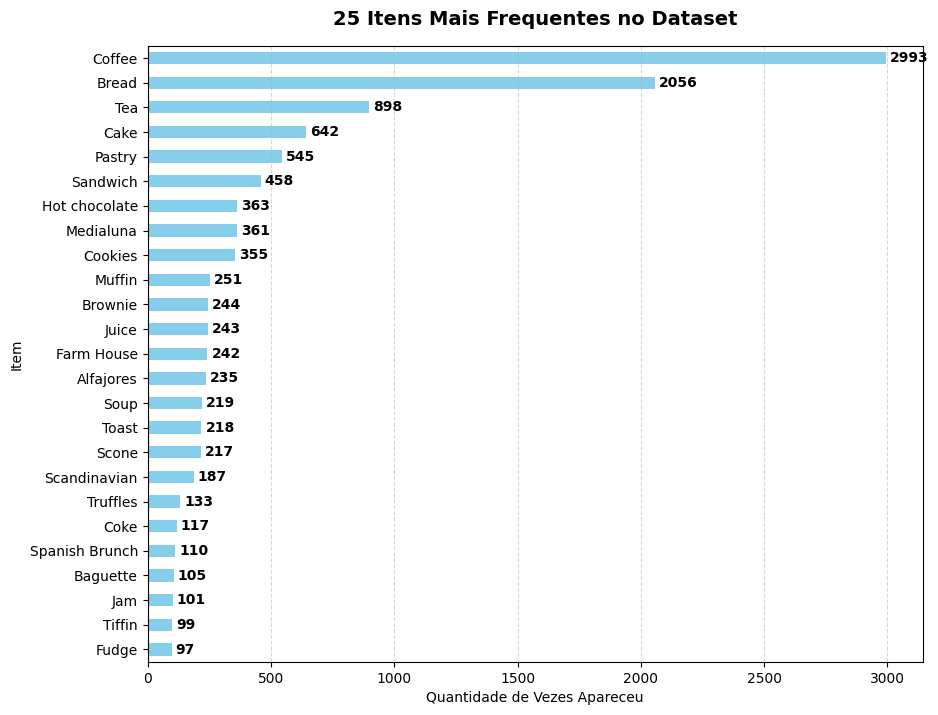

In [ ]:
contagem_itens = df['Item'].value_counts()

pd.set_option('display.max_rows', None)

print("--- CONTAGEM DE VEZES QUE CADA ITEM APARECE (LISTA COMPLETA) ---")
print(contagem_itens)

pd.reset_option('display.max_rows')

plt.figure(figsize=(10, 8))
top_20 = contagem_itens.head(25)

ax = top_20.plot(kind='barh', color='skyblue')
ax.invert_yaxis()

ax.bar_label(ax.containers[0], padding=3, weight='bold')

plt.title('25 Itens Mais Frequentes no Dataset', fontsize=14, pad=15, weight='bold')
plt.xlabel('Quantidade de Vezes Apareceu')
plt.ylabel('Item')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

In [ ]:
contagem = df['Item'].value_counts().reset_index()
contagem.columns = ['Item', 'Quantidade']

total_transacoes = 9465
contagem['Suporte (%)'] = (contagem['Quantidade'] / total_transacoes) * 100

itens_corte_1_porcento = contagem[contagem['Suporte (%)'] >= 1]

itens_corte_1_porcento

,Item,Quantidade,Suporte (%)
0,Coffee,2993,31.621764
1,Bread,2056,21.722134
2,Tea,898,9.487586
3,Cake,642,6.782884
4,Pastry,545,5.758056
5,Sandwich,458,4.838880
6,Hot chocolate,363,3.835182
7,Medialuna,361,3.814052
8,Cookies,355,3.750660
9,Muffin,251,2.651875


In [ ]:
lista_itens_validos = itens_corte_1_porcento['Item'].tolist()

df = df[df['Item'].isin(lista_itens_validos)]

print(f"Total de linhas antes do corte: {df.shape[0]}")
print(f"Total de linhas após o corte de 1%: {df.shape[0]}")
print(f"Quantidade de itens únicos que sobraram: {df['Item'].nunique()}")

Total de linhas antes do corte: 11489
Total de linhas após o corte de 1%: 11489
Quantidade de itens únicos que sobraram: 25


In [ ]:
# Opção 1: Lista simples com todas as colunas
print(df.columns.tolist())

['Transaction', 'Item', 'period_day', 'weekday_weekend', 'hour', 'day_of_week', 'month']


In [ ]:
df = pd.get_dummies(df, columns=['Item'], dtype=int)

print(df)

       Transaction period_day weekday_weekend  hour day_of_week  month  \
0                1    morning         weekend     9           7     10   
1                3    morning         weekend    10           7     10   
2                3    morning         weekend    10           7     10   
3                3    morning         weekend    10           7     10   
4                4    morning         weekend    10           7     10   
...            ...        ...             ...   ...         ...    ...   
13597         9681  afternoon         weekend    14           7      4   
13598         9681  afternoon         weekend    14           7      4   
13599         9681  afternoon         weekend    14           7      4   
13601         9683  afternoon         weekend    14           7      4   
13602         9683  afternoon         weekend    14           7      4   

       Item_Alfajores  Item_Baguette  Item_Bread  Item_Brownie  ...  \
0                   0              0    

### Coluna Period_Day

In [ ]:
df.loc[(df['hour'] >= 0) & (df['hour'] < 6), 'period_day'] = 'dawn'

df_periodos = pd.get_dummies(df['period_day'], prefix='', prefix_sep='', dtype=int)

df = pd.concat([df, df_periodos], axis=1)

df = df.drop(columns=['period_day'], errors='ignore')

print("--- Primeiras Linhas do DataFrame ---")
print(df.head())

print("\n--- Colunas Atuais ---")
print(df.columns.tolist())

--- Primeiras Linhas do DataFrame ---
   Transaction weekday_weekend  hour day_of_week  month  Item_Alfajores  \
0            1         weekend     9           7     10               0   
1            3         weekend    10           7     10               0   
2            3         weekend    10           7     10               0   
3            3         weekend    10           7     10               0   
4            4         weekend    10           7     10               0   

   Item_Baguette  Item_Bread  Item_Brownie  Item_Cake  ...  \
0              0           1             0          0  ...   
1              0           0             0          0  ...   
2              0           0             0          0  ...   
3              0           0             0          0  ...   
4              0           0             0          0  ...   

   Item_Spanish Brunch  Item_Tea  Item_Tiffin  Item_Toast  Item_Truffles  \
0                    0         0            0           0     

In [ ]:
total_mudados = df['dawn'].sum()

print("--- Auditoria de Alteração de Período ---")
print(f"Total de registros alterados para 'dawn' (00h às 05h59): {total_mudados}")

print("\n Distribuição total das vendas por período:")
for periodo in ['dawn', 'morning', 'afternoon', 'evening', 'night']:
    if periodo in df.columns:
        print(f"- {periodo}: {df[periodo].sum()} compras")

--- Auditoria de Alteração de Período ---
Total de registros alterados para 'dawn' (00h às 05h59): 1

 Distribuição total das vendas por período:
- dawn: 1 compras
- morning: 4861 compras
- afternoon: 6376 compras
- evening: 249 compras
- night: 2 compras


In [ ]:
if 'dawn' in df.columns:
    df = df[df['dawn'] == 0]
if 'night' in df.columns:
    df = df[df['night'] == 0]

colunas_para_excluir = ['dawn', 'night']
df = df.drop(columns=colunas_para_excluir, errors='ignore')

print("--- Nova Distribuição das Vendas por Período ---")
for periodo in ['morning', 'afternoon', 'evening']:
    if periodo in df.columns:
        print(f"- {periodo}: {df[periodo].sum()} compras")

print("\n Colunas atuais do DataFrame:")
print(df.columns.tolist())

--- Nova Distribuição das Vendas por Período ---
- morning: 4861 compras
- afternoon: 6376 compras
- evening: 249 compras

 Colunas atuais do DataFrame:
['Transaction', 'weekday_weekend', 'hour', 'day_of_week', 'month', 'Item_Alfajores', 'Item_Baguette', 'Item_Bread', 'Item_Brownie', 'Item_Cake', 'Item_Coffee', 'Item_Coke', 'Item_Cookies', 'Item_Farm House', 'Item_Fudge', 'Item_Hot chocolate', 'Item_Jam', 'Item_Juice', 'Item_Medialuna', 'Item_Muffin', 'Item_Pastry', 'Item_Sandwich', 'Item_Scandinavian', 'Item_Scone', 'Item_Soup', 'Item_Spanish Brunch', 'Item_Tea', 'Item_Tiffin', 'Item_Toast', 'Item_Truffles', 'afternoon', 'evening', 'morning']


### Coluna Weekday_Weekend

In [ ]:
dummies = pd.get_dummies(df['weekday_weekend'], dtype=int)
df = pd.concat([df.drop('weekday_weekend', axis=1), dummies], axis=1)

print("--- Primeiras Linhas do DataFrame ---")
print(df.head())

print("\n--- Colunas Atuais ---")
print(df.columns.tolist())

--- Primeiras Linhas do DataFrame ---
   Transaction  hour day_of_week  month  Item_Alfajores  Item_Baguette  \
0            1     9           7     10               0              0   
1            3    10           7     10               0              0   
2            3    10           7     10               0              0   
3            3    10           7     10               0              0   
4            4    10           7     10               0              0   

   Item_Bread  Item_Brownie  Item_Cake  Item_Coffee  ...  Item_Spanish Brunch  \
0           1             0          0            0  ...                    0   
1           0             0          0            0  ...                    0   
2           0             0          0            0  ...                    0   
3           0             0          0            0  ...                    0   
4           0             0          0            0  ...                    0   

   Item_Tea  Item_Tiffin  Item

## Regras de Associação

### Regras de Associação gerais

In [ ]:
colunas_itens = [col for col in df.columns if col.startswith('Item_')]
print(colunas_itens)
print(f"\nTotal de produtos encontrados: {len(colunas_itens)}")

['Item_Alfajores', 'Item_Baguette', 'Item_Bread', 'Item_Brownie', 'Item_Cake', 'Item_Coffee', 'Item_Coke', 'Item_Cookies', 'Item_Farm House', 'Item_Fudge', 'Item_Hot chocolate', 'Item_Jam', 'Item_Juice', 'Item_Medialuna', 'Item_Muffin', 'Item_Pastry', 'Item_Sandwich', 'Item_Scandinavian', 'Item_Scone', 'Item_Soup', 'Item_Spanish Brunch', 'Item_Tea', 'Item_Tiffin', 'Item_Toast', 'Item_Truffles']

Total de produtos encontrados: 25


In [ ]:
df_agrupado = df.groupby('Transaction')[colunas_itens].max().astype(bool)

In [ ]:
display(df_agrupado.head())

,Item_Alfajores,Item_Baguette,Item_Bread,Item_Brownie,Item_Cake,Item_Coffee,Item_Coke,Item_Cookies,Item_Farm House,Item_Fudge,...,Item_Pastry,Item_Sandwich,Item_Scandinavian,Item_Scone,Item_Soup,Item_Spanish Brunch,Item_Tea,Item_Tiffin,Item_Toast,Item_Truffles
Transaction,,,,,,,,,,,,,,,,,,,,,
1,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,True,False,False,True,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,True,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False


In [ ]:
itemsets_frequentes = apriori(df_agrupado, min_support=0.01, use_colnames=True)

regras = association_rules(itemsets_frequentes, metric="confidence", min_threshold=0.1)

regras_finais = (regras[regras['lift'] > 1].sort_values(by='lift', ascending=False))

display(regras_finais)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
15,(Item_Hot chocolate),(Item_Cake),0.059160,0.104919,0.011930,0.201657,1.922028,1.0,0.005723,1.121174,0.509881,0.078410,0.108078,0.157682
16,(Item_Cake),(Item_Hot chocolate),0.104919,0.059160,0.011930,0.113707,1.922028,1.0,0.005723,1.061545,0.535947,0.078410,0.057977,0.157682
40,"(Item_Coffee, Item_Tea)",(Item_Cake),0.051479,0.104919,0.010132,0.196825,1.875973,1.0,0.004731,1.114429,0.492286,0.069274,0.102679,0.146699
32,(Item_Toast),(Item_Coffee),0.035627,0.489132,0.025821,0.724771,1.481748,1.0,0.008395,1.856153,0.337132,0.051752,0.461251,0.388780
18,(Item_Cake),(Item_Tea),0.104919,0.146756,0.022389,0.213396,1.454085,1.0,0.006992,1.084718,0.348887,0.097648,0.078101,0.182978
17,(Item_Tea),(Item_Cake),0.146756,0.104919,0.022389,0.152561,1.454085,1.0,0.006992,1.056219,0.365994,0.097648,0.053227,0.182978
39,(Item_Pastry),"(Item_Coffee, Item_Bread)",0.089067,0.091518,0.011603,0.130275,1.423490,1.0,0.003452,1.044562,0.326589,0.068665,0.042661,0.128530
36,"(Item_Coffee, Item_Bread)",(Item_Pastry),0.091518,0.089067,0.011603,0.126786,1.423490,1.0,0.003452,1.043195,0.327470,0.068665,0.041407,0.128530
34,(Item_Sandwich),(Item_Tea),0.074849,0.146756,0.014708,0.196507,1.339002,1.0,0.003724,1.061918,0.273658,0.071090,0.058308,0.148365
35,(Item_Tea),(Item_Sandwich),0.146756,0.074849,0.014708,0.100223,1.339002,1.0,0.003724,1.028200,0.296721,0.071090,0.027427,0.148365


### Regras de Associação Segmentada por Weekday e Weekend

In [ ]:
# Agrupa por transação mantendo weekday e weekend
df_agrupado_days = (df.groupby('Transaction').agg({**{col: 'max' for col in colunas_itens}, 'weekday': 'max', 'weekend': 'max'}))

df_agrupado_days[colunas_itens] = df_agrupado_days[colunas_itens].astype(bool)

dados_dias_uteis = df_agrupado_days[df_agrupado_days['weekday'] == 1]
dados_fim_semana = df_agrupado_days[df_agrupado_days['weekend'] == 1]

cesta_dias_uteis = dados_dias_uteis[colunas_itens].astype(bool)
cesta_fim_semana = dados_fim_semana[colunas_itens].astype(bool)

itemsets_dias_uteis = apriori(cesta_dias_uteis, min_support=0.01, use_colnames=True)
itemsets_fim_semana = apriori(cesta_fim_semana, min_support=0.01, use_colnames=True)

regras_dias_uteis = association_rules(itemsets_dias_uteis, metric='confidence', min_threshold=0.1, num_itemsets=len(itemsets_dias_uteis))
regras_fim_semana = association_rules(itemsets_fim_semana, metric='confidence', min_threshold=0.1, num_itemsets=len(itemsets_fim_semana))

regras_dias_uteis = (regras_dias_uteis[regras_dias_uteis['lift'] > 1].sort_values(by='lift', ascending=False))
regras_fim_semana = (regras_fim_semana[regras_fim_semana['lift'] > 1].sort_values(by='lift', ascending=False))

print("\nREGRAS - DIAS ÚTEIS")
display(regras_dias_uteis)

print("\nREGRAS - FINAIS DE SEMANA")
display(regras_fim_semana)



REGRAS - DIAS ÚTEIS


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
13,(Item_Hot chocolate),(Item_Cake),0.051308,0.098592,0.011318,0.220588,2.237395,1.0,0.006259,1.156524,0.582962,0.081670,0.135340,0.167692
14,(Item_Cake),(Item_Hot chocolate),0.098592,0.051308,0.011318,0.114796,2.237395,1.0,0.006259,1.071721,0.613542,0.081670,0.066922,0.167692
32,(Item_Soup),(Item_Tea),0.042254,0.148893,0.010815,0.255952,1.719032,1.0,0.004524,1.143887,0.436731,0.059972,0.125788,0.164294
27,(Item_Toast),(Item_Coffee),0.038984,0.490191,0.028421,0.729032,1.487241,1.0,0.009311,1.881437,0.340904,0.056755,0.468491,0.393505
16,(Item_Cake),(Item_Tea),0.098592,0.148893,0.021630,0.219388,1.473456,1.0,0.006950,1.090307,0.356468,0.095768,0.082827,0.182329
15,(Item_Tea),(Item_Cake),0.148893,0.098592,0.021630,0.145270,1.473456,1.0,0.006950,1.054612,0.377536,0.095768,0.051784,0.182329
31,(Item_Tea),(Item_Sandwich),0.148893,0.078722,0.016097,0.108108,1.373284,1.0,0.004375,1.032948,0.319371,0.076100,0.031897,0.156290
30,(Item_Sandwich),(Item_Tea),0.078722,0.148893,0.016097,0.204473,1.373284,1.0,0.004375,1.069865,0.295045,0.076100,0.065303,0.156290
33,"(Item_Coffee, Item_Bread)",(Item_Pastry),0.084256,0.090543,0.010060,0.119403,1.318740,1.0,0.002432,1.032773,0.263938,0.061069,0.031733,0.115257
36,(Item_Pastry),"(Item_Coffee, Item_Bread)",0.090543,0.084256,0.010060,0.111111,1.318740,1.0,0.002432,1.030213,0.265763,0.061069,0.029326,0.115257



REGRAS - FINAIS DE SEMANA


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
62,(Item_Cake),"(Item_Coffee, Item_Tea)",0.116659,0.061129,0.012133,0.104000,1.701313,1.0,0.005001,1.047847,0.466659,0.073239,0.045662,0.151237
59,"(Item_Coffee, Item_Tea)",(Item_Cake),0.061129,0.116659,0.012133,0.198473,1.701313,1.0,0.005001,1.102073,0.439058,0.073239,0.092619,0.151237
58,(Item_Pastry),"(Item_Coffee, Item_Bread)",0.086328,0.104993,0.014466,0.167568,1.595988,1.0,0.005402,1.075171,0.408712,0.081794,0.069915,0.152673
55,"(Item_Coffee, Item_Bread)",(Item_Pastry),0.104993,0.086328,0.014466,0.137778,1.595988,1.0,0.005402,1.059672,0.417236,0.081794,0.056311,0.152673
38,(Item_Pastry),(Item_Medialuna),0.086328,0.078395,0.010733,0.124324,1.585875,1.0,0.003965,1.052450,0.404339,0.069697,0.049836,0.130615
39,(Item_Medialuna),(Item_Pastry),0.078395,0.086328,0.010733,0.136905,1.585875,1.0,0.003965,1.058600,0.400859,0.069697,0.055356,0.130615
41,(Item_Tea),(Item_Scone),0.142790,0.063929,0.014466,0.101307,1.584681,1.0,0.005337,1.041592,0.430418,0.075243,0.039931,0.163792
42,(Item_Scone),(Item_Tea),0.063929,0.142790,0.014466,0.226277,1.584681,1.0,0.005337,1.107903,0.394156,0.075243,0.097394,0.163792
19,(Item_Cake),(Item_Hot chocolate),0.116659,0.073728,0.013066,0.112000,1.519089,1.0,0.004465,1.043099,0.386839,0.073684,0.041318,0.144608
18,(Item_Hot chocolate),(Item_Cake),0.073728,0.116659,0.013066,0.177215,1.519089,1.0,0.004465,1.073599,0.368910,0.073684,0.068554,0.144608


#### Regras exclusivas de cada subset

In [ ]:
regras_dias_uteis['regra'] = (regras_dias_uteis['antecedents'].astype(str) + " -> " + regras_dias_uteis['consequents'].astype(str))
regras_fim_semana['regra'] = (regras_fim_semana['antecedents'].astype(str) + " -> " + regras_fim_semana['consequents'].astype(str))

exclusivas_weekday = set(regras_dias_uteis['regra']) - set(regras_fim_semana['regra'])
exclusivas_weekend = set(regras_fim_semana['regra']) - set(regras_dias_uteis['regra'])

print("\nREGRAS EXCLUSIVAS DOS DIAS ÚTEIS\n")
display(regras_dias_uteis[regras_dias_uteis['regra'].isin(exclusivas_weekday)][['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False))

print("\nREGRAS EXCLUSIVAS DOS FINAIS DE SEMANA\n")
display(regras_fim_semana[regras_fim_semana['regra'].isin(exclusivas_weekend)][['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False))

print("Quantidade de Regras Exclusivas dos Dias Úteis", len(exclusivas_weekday))
print("Quantidade de Regras Exclusivas dos Finais de Semana", len(exclusivas_weekend))


REGRAS EXCLUSIVAS DOS DIAS ÚTEIS



,antecedents,consequents,support,confidence,lift
32,(Item_Soup),(Item_Tea),0.010815,0.255952,1.719032
31,(Item_Tea),(Item_Sandwich),0.016097,0.108108,1.373284
28,(Item_Cookies),(Item_Tea),0.011066,0.173228,1.163439
22,(Item_Coffee),(Item_Pastry),0.050302,0.102617,1.133345
21,(Item_Muffin),(Item_Coffee),0.017606,0.492958,1.005644



REGRAS EXCLUSIVAS DOS FINAIS DE SEMANA



,antecedents,consequents,support,confidence,lift
62,(Item_Cake),"(Item_Coffee, Item_Tea)",0.012133,0.104000,1.701313
59,"(Item_Coffee, Item_Tea)",(Item_Cake),0.012133,0.198473,1.701313
38,(Item_Pastry),(Item_Medialuna),0.010733,0.124324,1.585875
39,(Item_Medialuna),(Item_Pastry),0.010733,0.136905,1.585875
41,(Item_Tea),(Item_Scone),0.014466,0.101307,1.584681
42,(Item_Scone),(Item_Tea),0.014466,0.226277,1.584681
32,(Item_Spanish Brunch),(Item_Coffee),0.022865,0.710145,1.457702
50,(Item_Hot chocolate),"(Item_Coffee, Item_Bread)",0.010733,0.145570,1.386470
47,"(Item_Coffee, Item_Bread)",(Item_Hot chocolate),0.010733,0.102222,1.386470
51,"(Item_Coffee, Item_Bread)",(Item_Medialuna),0.011199,0.106667,1.360635


Quantidade de Regras Exclusivas dos Dias Úteis 5
Quantidade de Regras Exclusivas dos Finais de Semana 25


### Visualizar regras

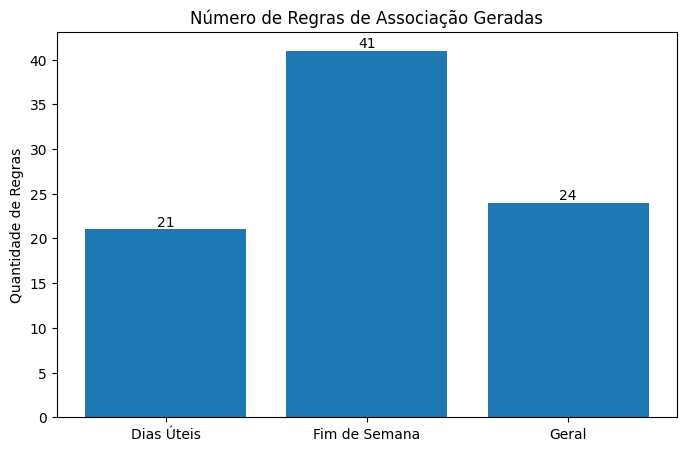

In [ ]:
plt.figure(figsize=(8,5))

categorias = ["Dias Úteis", "Fim de Semana", "Geral"]
valores = [
    len(regras_dias_uteis),
    len(regras_fim_semana),
    len(regras_finais)
]

barras = plt.bar(categorias, valores)

for barra in barras:
    altura = barra.get_height()

    plt.text(barra.get_x() + barra.get_width()/2, altura, f'{int(altura)}', ha='center', va='bottom')

plt.ylabel("Quantidade de Regras")
plt.title("Número de Regras de Associação Geradas")

plt.show()

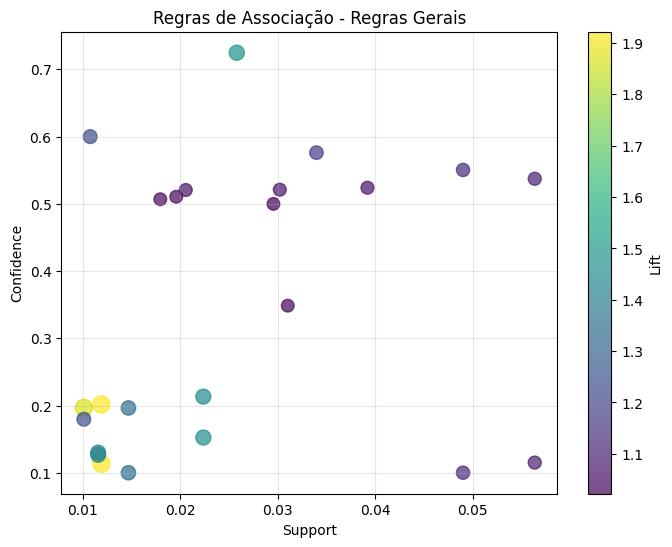

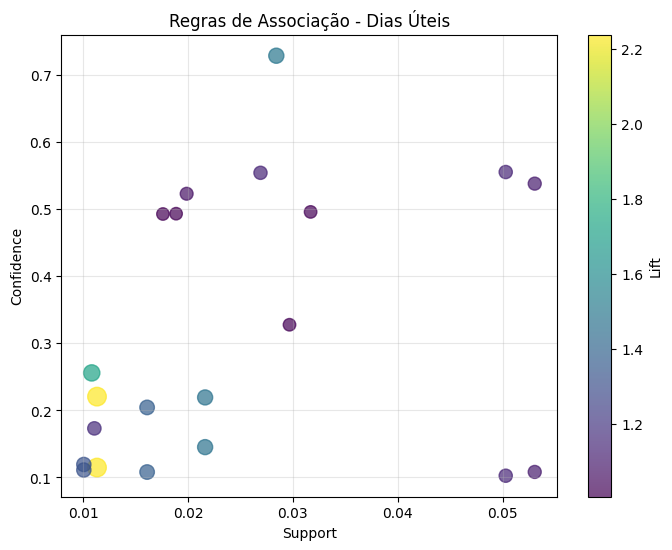

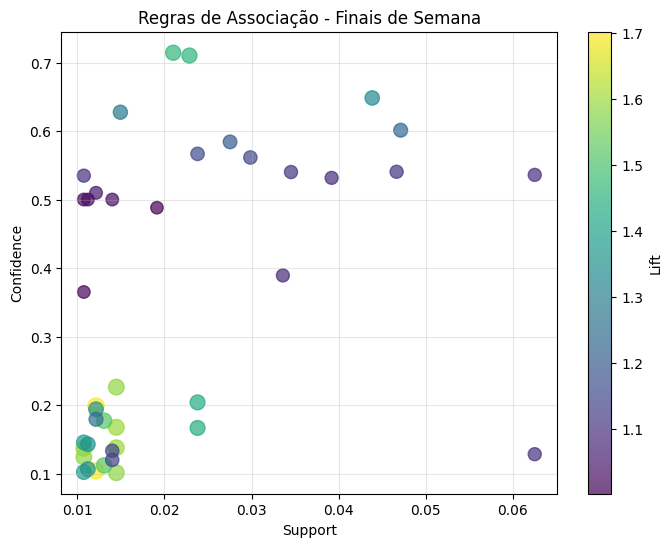

In [ ]:
def plot_regras_scatter(regras, titulo):
    plt.figure(figsize=(8,6))
    sc = plt.scatter(regras['support'], regras['confidence'], c=regras['lift'], s=regras['lift'] * 80, cmap='viridis', alpha=0.7)

    plt.colorbar(sc, label='Lift')
    plt.title(titulo)
    plt.xlabel('Support')
    plt.ylabel('Confidence')
    plt.grid(alpha=0.3)

    plt.show()

plot_regras_scatter(regras_finais, "Regras de Associação - Regras Gerais")
print("\n")
plot_regras_scatter(regras_dias_uteis, "Regras de Associação - Dias Úteis")
print("\n")
plot_regras_scatter(regras_fim_semana, "Regras de Associação - Finais de Semana")


#### Grafo de Regras de Associação

Este gráfico representa visualmente as regras de associação encontradas pelo algoritmo **Apriori**.

### Como interpretar o grafo
##### Nós

Cada nó representa um produto (ou conjunto de produtos).

Exemplo:

- Coffee
- Toast
- Cake
- Tea

O tamanho do nó é proporcional ao seu **support** (frequência de ocorrência no conjunto de dados).

Assim:

- nós maiores → produtos mais frequentes;
- nós menores → produtos menos frequentes.

##### Arestas

As setas representam as regras de associação descobertas.

Exemplo:

```
Coffee → Toast
```

Significa que transações contendo **Coffee** apresentam maior tendência de também conter **Toast**.

A direção da seta indica:

- origem = antecedente;
- destino = consequente.

### Métricas das regras

##### Support

Representa a frequência da combinação no conjunto de dados.

$$
Support(A \rightarrow B) = P(A \cap B)
$$

Quanto maior o support, mais comum é a combinação.

##### Confidence

Representa a probabilidade de ocorrer o consequente dado que o antecedente ocorreu.

$$
Confidence(A \rightarrow B)=\frac{Support(A \cap B)}{Support(A)}
$$

Exemplo:

```
Confidence = 0.72
```

Significa que aproximadamente **72%** das transações contendo o antecedente também contêm o consequente.

##### Lift

Mede a força da associação entre os itens.

$$
Lift(A \rightarrow B)=\frac{Confidence(A \rightarrow B)}{Support(B)}
$$

Interpretação:

- Lift = 1 → itens independentes;
- Lift > 1 → associação positiva;
- Lift < 1 → associação negativa.

Quanto maior o lift, mais forte a relação entre os produtos.

### Objetivo da visualização

O grafo facilita a identificação de:

- produtos mais frequentes
- produtos fortemente associados
- padrões de compra
- oportunidades de venda conjunta
- comportamentos de compra em diferentes contextos

In [ ]:
def plot_association_network(rules, top_n=30, filename="association_network.html", notebook=True):

    net = Network(height="800px", width="100%", directed=True, notebook=notebook, cdn_resources="in_line")
    net.repulsion()
    regras_plot = (rules.sort_values("lift", ascending=False).head(top_n))

    for _, row in regras_plot.iterrows():
        antecedente = ", ".join(list(row["antecedents"]))
        consequente = ", ".join(list(row["consequents"]))

        suporte_ant = row["antecedent support"]
        suporte_cons = row["consequent support"]

        confianca = row["confidence"]
        lift = row["lift"]

        net.add_node(antecedente, shape="dot", value=suporte_ant * 100, title=(f"{antecedente}<br>" f"Support: {suporte_ant:.3f}"))

        net.add_node(consequente, shape="dot", value=suporte_cons * 100, title=(f"{consequente}<br>" f"Support: {suporte_cons:.3f}"))

        net.add_edge(antecedente, consequente, value=lift, title=(f"Confidence: {confianca:.3f}<br>" f"Lift: {lift:.3f}"), arrowStrikethrough=False)

    net.set_edge_smooth("continuous")
    net.toggle_hide_edges_on_drag(True)

    net.save_graph(filename)

    return net

In [ ]:
plot_association_network(regras_finais, filename="regras_finais.html")
HTML(filename="regras_finais.html")


In [ ]:
plot_association_network(regras_dias_uteis, filename="dias_uteis.html")
HTML(filename="dias_uteis.html")

In [ ]:
plot_association_network(regras_fim_semana, filename="fim_de_semana.html")
HTML(filename="fim_de_semana.html")